# Stage 2
# I. Exploratory Data Analysis (EDA)

**Goal of this step:** We want to determine whether loyal and non-loyal clients behave differently enough to justify training separate demand prediction models. We compare the two groups across demand levels, distance sensitivity, geographic spread, and firm characteristics.

>Note: This notebook is for visualization purpose. Most functions are defined in the `handlers/eda_handlers.py` file.

In [ ]:
import sys
sys.path.append('handlers')
import matplotlib.pyplot as plt
import handlers.eda_handlers as eda
import pandas as pd

df = eda.load_historic()
print(f"{len(df)} historic clients — {df['loyal'].sum()} loyal ({df['loyal'].mean():.0%}), {(df['loyal'] == 0).sum()} non-loyal")

500 historic clients — 105 loyal (21%), 395 non-loyal


## 1. Demand Distribution

First comparison: do loyal clients generate higher or more stable demand than non-loyal ones?

In [2]:
eda.demand_summary(df)

,n,mean,median,std,min,max
loyal,,,,,,
Non-Loyal,395,49.08,49.91,34.08,0.00,125.90
Loyal,105,84.25,83.66,30.52,16.88,142.63


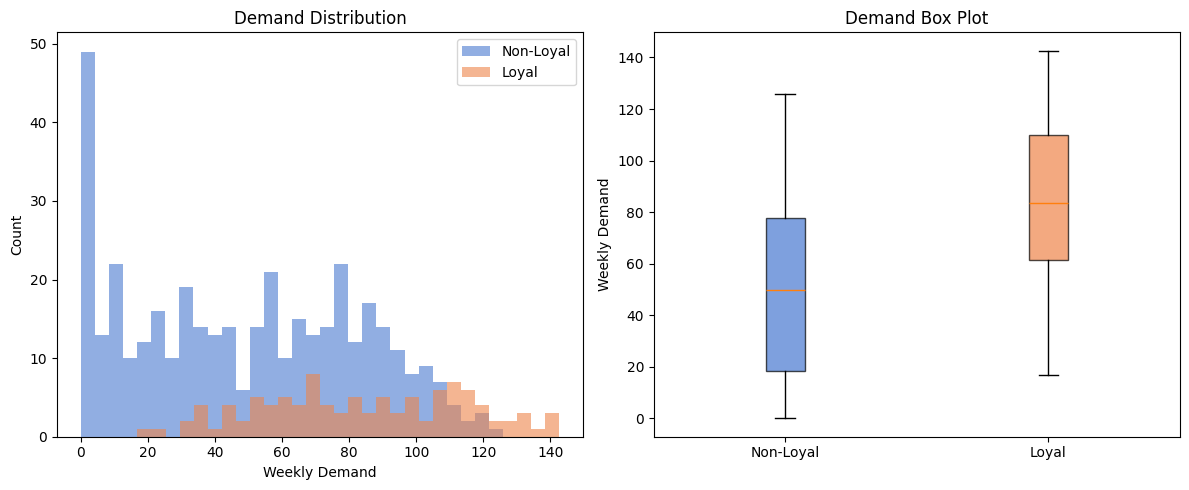

In [3]:
eda.plot_demand_distribution(df)
plt.show()

## 2. Distance Sensitivity

A key assumption is that demand decreases with distance. We check whether the two groups respond to distance differently — a different slope means a different model is needed for each.

In [4]:
eda.distance_sensitivity_table(df)

,Pearson r,Slope (demand / dist unit)
Group,,
Non-Loyal,-0.279,-0.805
Loyal,0.013,0.055


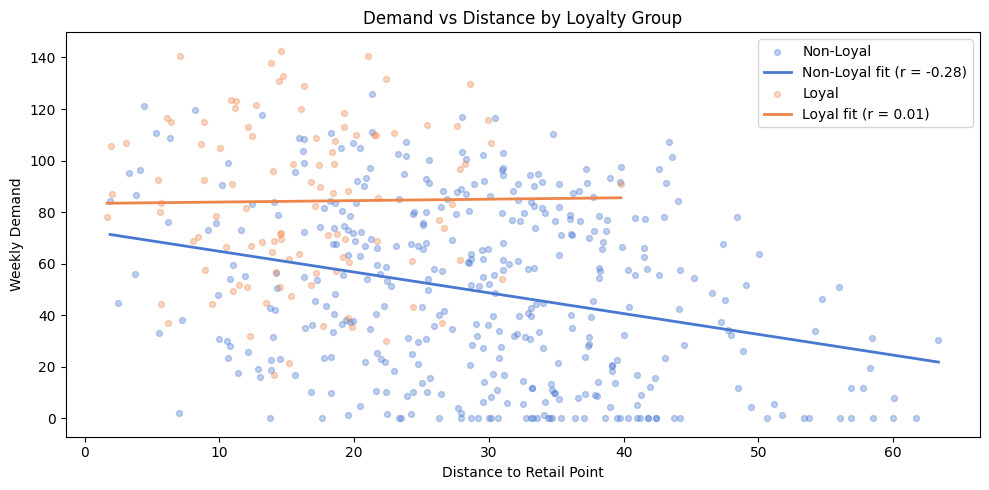

In [5]:
eda.plot_demand_vs_distance(df)
plt.show()

## 3. Geographic Distribution

We check whether loyalty is uniformly spread across the city or concentrated in specific areas, which would affect store placement decisions.

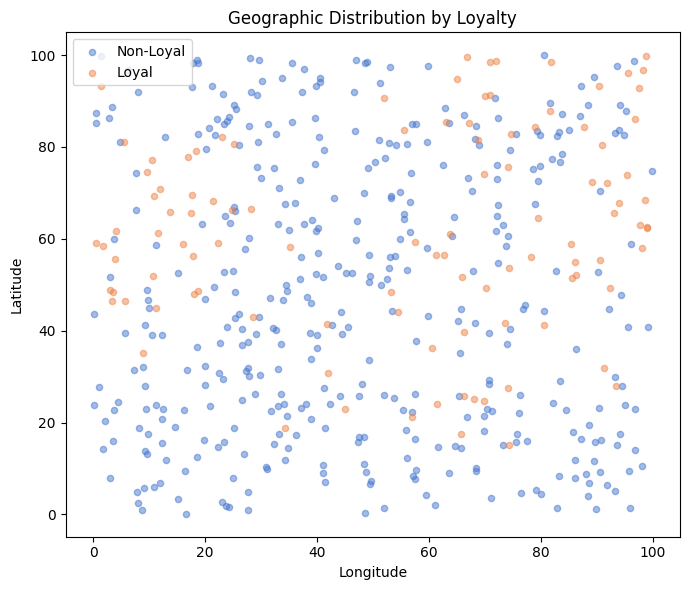

In [6]:
eda.plot_geographic_distribution(df)
plt.show()

## 4. Client Profile Comparison

We compare firm characteristics (size, age, volume, staff) between groups to see whether loyal clients have a distinct profile.

In [7]:
eda.feature_means(df)

,employes,surface,firm_age,monthly_volume,purchase_staff,dist_retail_point
loyal,,,,,,
Non-Loyal,230.48,1018.85,24.96,79.46,4.92,29.51
Loyal,333.15,1121.68,26.97,91.02,4.98,16.12


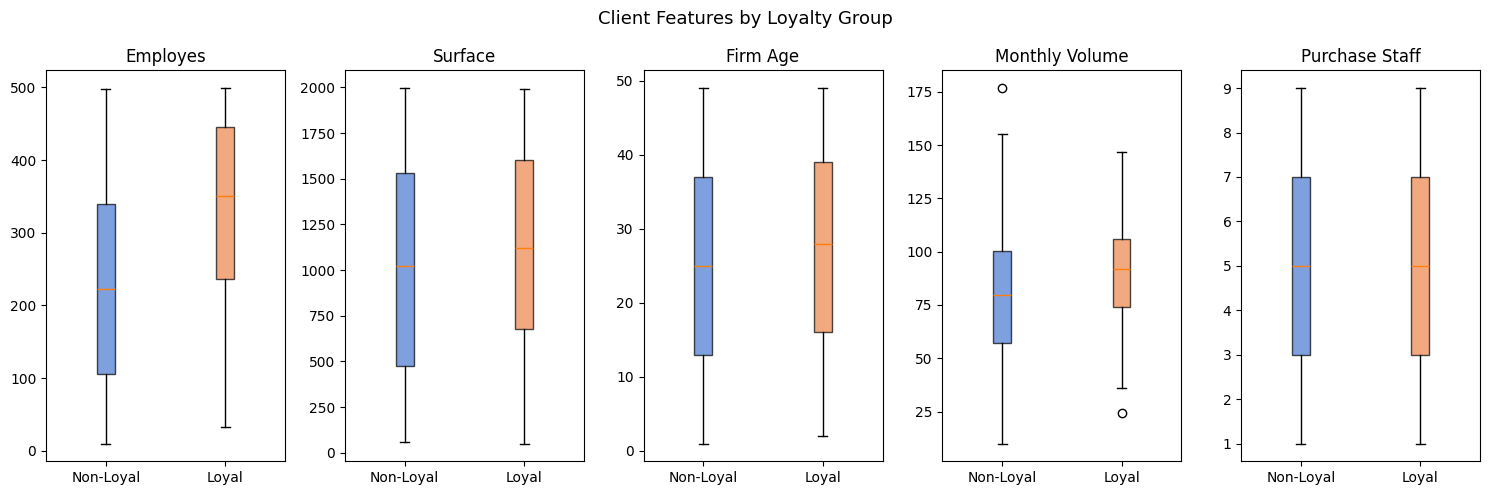

In [8]:
eda.plot_feature_comparison(df)
plt.show()

## Main takeaways after EDA

Based on this EDA, we see that:

### 1. Loyal clients generate a lot more demand
We see that loyal clients buy around 70% more per week on avaerage (84 against 49 units). No loyal client has 0 demand, while 40 non-loyal clients (around 10% of non-loyal clients) buy nothing.
=> **loyal clients demand is higher and easier to predict**.

### 2. Distance affects the two groups in different ways:
**For non-loyal clients:**

Every additional distance unit costs around 0.8 units of weekly demand (cf. distance table). => **Those clients buy less the farther teh store is**.

**For loyal clients:**

The slope is essentially 0 (cf. demand vs distance loyalty group fit). This means **demands stays the same regardless of the distance to the store**.

### 3. Clients profile
The loyal clients have in general more employees, more monthly transaction volume and larger premise than non loyal clients. **This means they are larger companies who can pay more**.
They are also generaly (around 45%) closer to the stores (16km average vs 30km average) which means that **companies that were already close to the stores were more likely to be loyal**.


# II. Loyalty Classifier

**Goal of this step:** We want to predict whether each potential client in Valmontier will join the loyalty program. 

What we know is loyalty may depend on the distance to the assigned store but we cannot know that distance until we actually open a store. 

To get around this we predict loyalty for every possible client+ site pair and build a loyalty matrix. This matrix will feed directly into the demand estimation step.

>Note: Most functions are defined in the `handlers/classifier_handlers.py` file (for notebook clarity).

In [9]:
import sys
sys.path.append('handlers')
import numpy as np
import matplotlib.pyplot as plt
import handlers.classifier_handlers as ch

historic, potential, sites = ch.load_data()
print(f"Historic clients : {len(historic)} rows  |  Loyal: {historic['loyal'].sum()} ({historic['loyal'].mean():.0%})")
print(f"Potential clients: {len(potential)} rows")
print(f"Candidate sites  : {len(sites)} sites")

Historic clients : 500 rows  |  Loyal: 105 (21%)
Potential clients: 200 rows
Candidate sites  : 8 sites


## 1. Features & train/test split

We use the features that are available for both historic and potential clients: `employes`, `surface`, `firm_age`, `monthly_volume`, `purchase_staff`, and `dist_retail_point`. We drop `purchased_products` 

> `purchased_products` is in the historic data but not in the potential clients dataset, so we can't use it for prediction.

Since only 21% of historic clients are loyal, we have data unbalance that will skew the models into thinking everyone is non-loyal. We use `class_weight='balanced'` on both models to force them to actually learn the loyal class.

In [10]:
X_train, X_test, y_train, y_test = ch.split_data(historic, test_size=0.2)
print(f"Train: {len(X_train)} samples  |  Test: {len(X_test)} samples")
print(f"Loyal share — train: {y_train.mean():.0%}  |  test: {y_test.mean():.0%}")

Train: 400 samples  |  Test: 100 samples
Loyal share — train: 21%  |  test: 21%


## 2. Model training & evaluation

We train two classifiers and compare them:
- **Logistic Regression**: simplest classifier, features are standardised internally before fitting
- **Random Forest**: classifier that handles non-linear patterns between features (usually gives better results on tabular data).

We will look at the classification report and ROC curve to decide which one to use for the loyalty matrix.

In [11]:
lr, rf = ch.train_classifiers(X_train, y_train)
NAMES  = ["Logistic Regression", "Random Forest"]
MODELS = [lr, rf]

ch.evaluation_report(MODELS, NAMES, X_test, y_test)

 Logistic Regression   (ROC AUC = 0.857)
              precision    recall  f1-score   support

   Non-Loyal       0.94      0.81      0.87        79
       Loyal       0.53      0.81      0.64        21

    accuracy                           0.81       100
   macro avg       0.74      0.81      0.76       100
weighted avg       0.86      0.81      0.82       100

 Random Forest   (ROC AUC = 0.866)
              precision    recall  f1-score   support

   Non-Loyal       0.86      0.96      0.91        79
       Loyal       0.75      0.43      0.55        21

    accuracy                           0.85       100
   macro avg       0.81      0.70      0.73       100
weighted avg       0.84      0.85      0.83       100



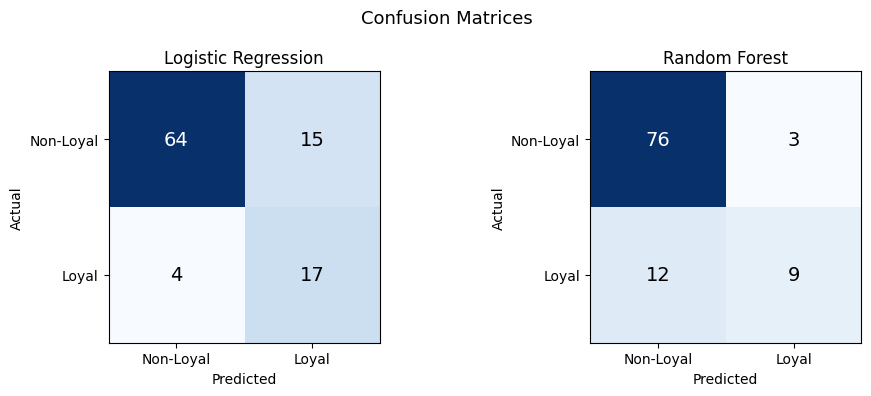

In [12]:
ch.plot_confusion_matrices(MODELS, NAMES, X_test, y_test)
plt.show()

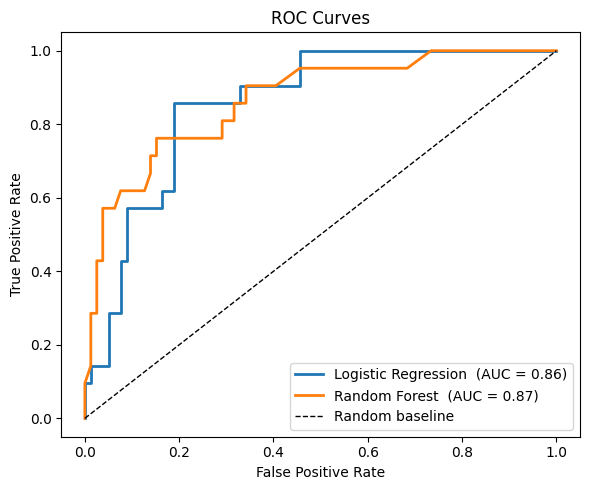

In [13]:
ch.plot_roc_curves(MODELS, NAMES, X_test, y_test)
plt.show()

## 3. Building the loyalty matrix

We take the chosen model and run it on all 200 potential clients *8 candidate sites. For each pair, we compute the Euclidean distance between the client and that site and combine it with the client's firm characteristics to get a prediction.

The output is a 200 *8 matrix of 0s and 1s  (1 meaning the client is predicted to be loyal if assigned to that site).

**Which model to choose:** Both models have a similar AUC (around 0.86), but the recall on the loyal class is very different: 
- LR catches 81% of actual loyal clients
- Random Forest only catches 43%. 

Since loyal clients buy around 72% more per week on average, missing them means we would underestimate demand for those client-site pairs. => **We should use Logistic Regression.**

In [14]:
best_model = lr  # Logistic Regression — higher recall on the loyal class (0.81 vs 0.43)

loyalty_matrix = ch.build_loyalty_matrix(best_model, potential, sites)
print(f"Loyalty matrix shape : {loyalty_matrix.shape}")
print(f"Overall predicted loyal share: {loyalty_matrix.mean():.1%}")
print()
print("Sample (first 5 clients, all 8 sites):")
print(loyalty_matrix[:5])

Loyalty matrix shape : (200, 8)
Overall predicted loyal share: 11.8%

Sample (first 5 clients, all 8 sites):
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 1 0 0 0 0 0 0]]


## 4. Predicted loyalty distribution per site

We check how many clients are predicted loyal for each candidate site. 

>Sites with more loyal clients around them will tend to attract higher and more stable demand.

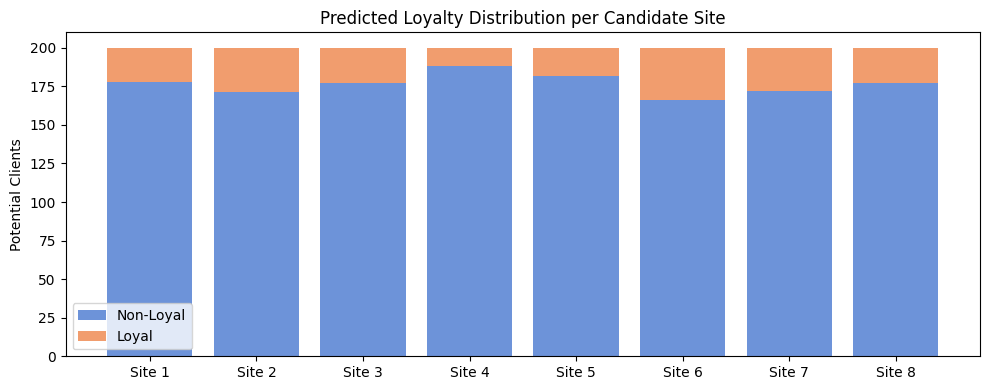

In [15]:
ch.plot_loyalty_matrix_summary(loyalty_matrix)
plt.show()

In [16]:
# Save loyalty matrix for use in the demand modelling notebook
np.save("loyalty_matrix.npy", loyalty_matrix)
print("Saved: loyalty_matrix.npy")

Saved: loyalty_matrix.npy


# III. Demand Models

**Goal of this step:** We train two separate linear regression models (one on loyal clients, one on non-loyal clients). Then combine them with the loyalty matrix from the previous step to build the 200*8 demand matrix that feeds the optimizer.

>Note: Functions are in `handlers/demand_handlers.py`. Distance computation and data loading are reused from `handlers/classifier_handlers.py`.

In [17]:
import sys
sys.path.append('handlers')
import numpy as np
import matplotlib.pyplot as plt
import handlers.demand_handlers as dh

historic, potential, sites = dh.load_data()
loyalty_matrix = np.load('loyalty_matrix.npy')

print(f"Historic: {len(historic)} clients | Potential: {len(potential)} clients | Sites: {len(sites)}")
print(f"Loyalty matrix: {loyalty_matrix.shape} — {loyalty_matrix.mean():.1%} predicted loyal")

Historic: 500 clients | Potential: 200 clients | Sites: 8
Loyalty matrix: (200, 8) — 11.8% predicted loyal


## 1. Split historic data by loyalty group

In [18]:
loyal, nonloyal = dh.split_by_loyalty(historic)
print(f"Loyal group    : {len(loyal)} clients")
print(f"Non-loyal group: {len(nonloyal)} clients")

splits = dh.get_splits(loyal, nonloyal)

Loyal group    : 105 clients
Non-loyal group: 395 clients


## 2. Train the models

We use linear regression on each group separately. The case expects demand to decrease linearly with distance, so this is the natural choice. Negative predictions will be clipped to 0 when building the demand matrix.

In [19]:
models = dh.train_demand_models(splits)
print("Models trained:", list(models.keys()))

Models trained: ['Loyal', 'Non-Loyal']


## 3. Evaluation

In [20]:
dh.evaluation_report(models, splits)

Group            R²     RMSE
----------------------------
Loyal         0.958     6.78
Non-Loyal     0.939     8.01


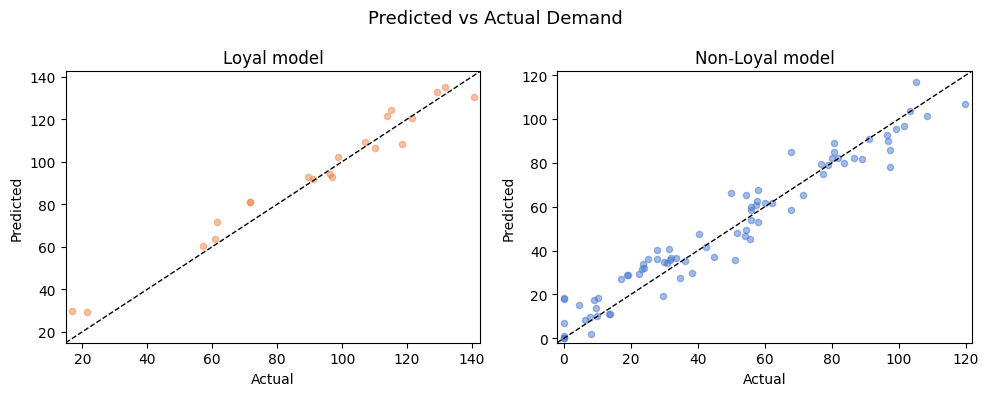

In [21]:
dh.plot_predictions_vs_actual(models, splits)
plt.show()

## 4. Build the demand matrix

For each (client, site) pair we compute the distance, look up the predicted loyalty from the loyalty matrix, and apply the matching model. => this gives us a 200*8 demand matrix ready for the optimizer.

In [22]:
demand_matrix = dh.build_demand_matrix(models, loyalty_matrix, potential, sites)

print(f"Demand matrix shape : {demand_matrix.shape}")
print(f"Overall mean demand : {demand_matrix.mean():.2f}")
print(f"Zero-demand entries : {(demand_matrix == 0).sum()} ({(demand_matrix == 0).mean():.1%})")

Demand matrix shape : (200, 8)
Overall mean demand : 38.47
Zero-demand entries : 348 (21.8%)


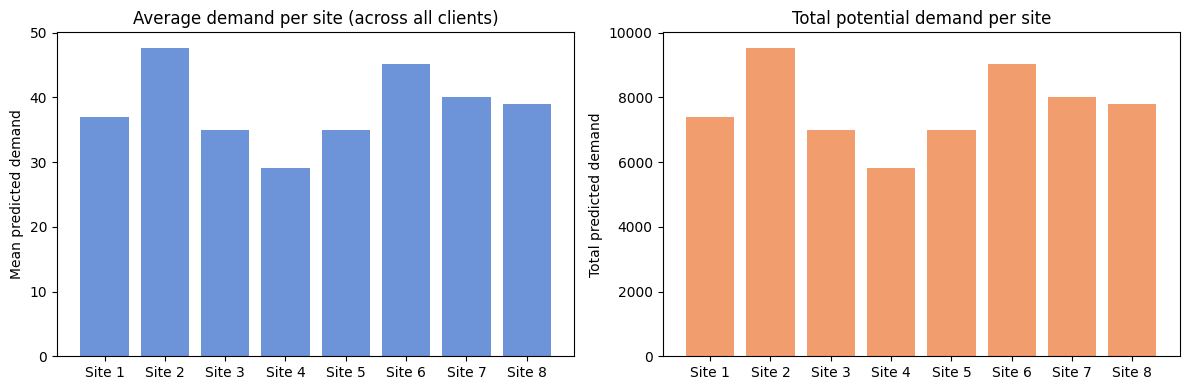

In [23]:
dh.plot_demand_matrix_summary(demand_matrix)
plt.show()

In [24]:
# Save for the optimization step
np.save('demand_matrix.npy', demand_matrix)
print('Saved: demand_matrix.npy')

Saved: demand_matrix.npy


# IV. Optimization

**Goal of this step:** We feed the 200*8 segmented demand matrix built in the previous notebook into the optimizer. The optimization model itself is unchanged from Stage 1 (only its input differs). The solver decides which sites to open, in what format, and which clients to assign where, maximizing total captured weekly demand within the 850 k euros budget.

>Note: Functions are in `handlers/optimization_handlers.py`. The solver is `opticlean_optimization.py` at the project root.

In [25]:
import sys
sys.path.append('handlers')
import matplotlib.pyplot as plt
import handlers.optimization_handlers as oh

demand_matrix, potential, sites = oh.load_inputs()
print(f"Demand matrix : {demand_matrix.shape}")
print(f"Non zero entries : {(demand_matrix > 0).sum()} / {demand_matrix.size}")

Demand matrix : (200, 8)
Non zero entries : 1252 / 1600


## 1. Run the optimizer

We pass the segmented demand matrix and the candidate sites data to `solve_location_model()`. The solver handles site selection, format choice and client assignment all at once.

In [26]:
result = oh.run_optimization(demand_matrix, sites, budget=850, verbose=True)

Restricted license - for non-production use only - expires 2027-11-29


Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 26.04 LTS")

CPU model: Intel(R) Core(TM) Ultra 7 258V, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1817 rows, 1616 columns and 7700 nonzeros (Max)
Model fingerprint: 0xb955614b
Model has 1252 linear objective coefficients
Variable types: 0 continuous, 1616 integer (1616 binary)
Coefficient statistics:
  Matrix range     [1e-01, 5e+03]
  Objective range  [1e-01, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 8e+02]

Found heuristic solution: objective -0.0000000
Presolve removed 364 rows and 348 columns
Presolve time: 0.03s
Presolved: 1453 rows, 1268 columns, 6303 nonzeros
Variable types: 0 continuous, 1268 integer (1268 binary)

Root relaxation: objective 1.324203e+04, 205 iterations, 0.02 seconds (0.01 work units)

    Nodes    |    Current Node    |     Objective Bounds     

## 2. Results

In [27]:
oh.print_summary(result)

Total captured demand : 13120.5 units/week
Budget used           : 806 / 850 k€
Clients assigned      : 189 / 200
Clients unassigned    : 11

 site_id format  capacity  cost  used_capacity  capacity_utilization
       0  small    2500.0 144.0    1912.345534              0.764938
       1  small    2800.0 158.0    2798.090701              0.999318
       4  small    2500.0 144.0    2284.850098              0.913940
       6  large    4200.0 207.0    3543.902597              0.843786
       7  small    2700.0 153.0    2581.291395              0.956034


## 3. Visualizations

The map shows each potential client colored by the store they are assigned to. Square markers are large format stores, triangles are small format, and crosses are sites that were not opened.

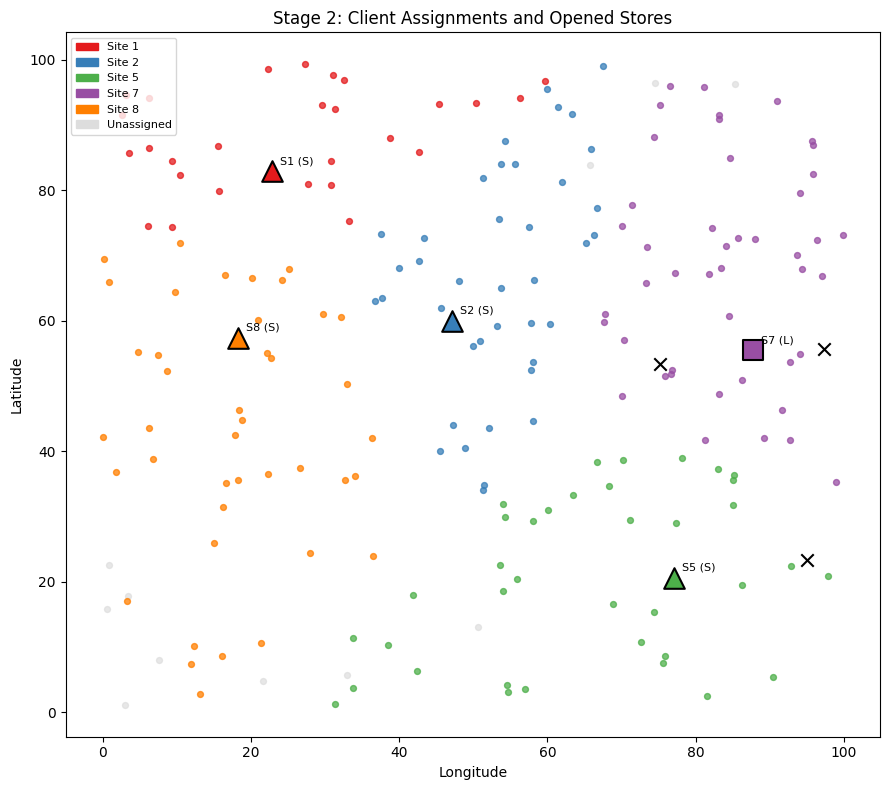

In [28]:
oh.plot_assignment_map(result, potential, sites)
plt.show()

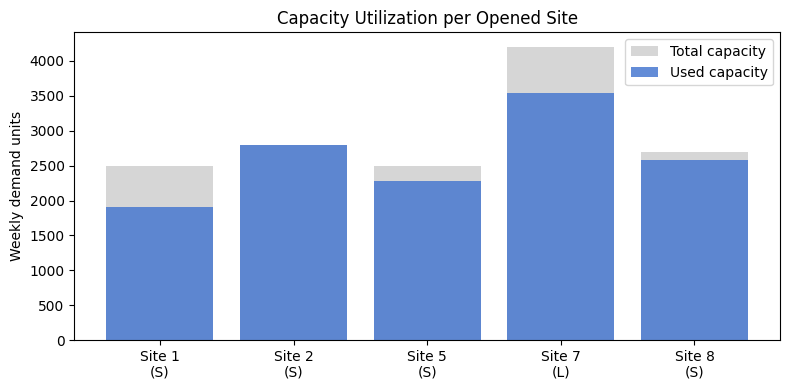

In [29]:
oh.plot_capacity_utilization(result)
plt.show()

# Stage 2: Comparison with Stage 1

We now compare the optimization decisions produced by Stage 1 (single demand model) against Stage 2 (segmented loyal/non-loyal models). The goal is to see whether the segmented approach captures more demand and whether it changes which stores we open.

In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '..')
import handlers.optimization_handlers as oh
from opticlean_optimization import solve_location_model

demand_s2, potential, sites = oh.load_inputs()

# Stage 1 demand matrix (classmate's single-model approach)
# index_col=0 drops the Client ID column so we get a clean 200x8 matrix
demand_s1 = pd.read_excel("../demand_matrix_stage1.xlsx", index_col=0).values

result_s1 = solve_location_model(demand_s1, sites, budget=850, verbose=False)
result_s2 = solve_location_model(demand_s2, sites, budget=850, verbose=False)

FileNotFoundError: [Errno 2] No such file or directory: '../stage_1/demand_matrix.npy'

In [ ]:
oh.compare_results(result_s1, result_s2, label1="Stage 1", label2="Stage 2")

In [ ]:
fig = oh.plot_comparison(result_s1, result_s2, label1="Stage 1", label2="Stage 2")
plt.show()

## Interpretation

### Retail store site decision
Both stages converge on **the exact same 5-store configuration**: Sites 1, 2, 5, 7 (large), and 8 (all small except 7), with a spending of **806 k€ out of 850 k€** and assigning **189 out of 200 clients**. So the optimizer did not need a different layout to benefit from the segmented approach.

### Difference in approach
The difference we can see is entirely in how much demand each site captures. 

Stage 2 extracts **13 120 units/week** versus 12 697 for Stage 1. This is a gain of around **+423 units/week, +3.3%** at zero extra cost because the site assignation is the same. We thus have a higher utilization across every opened site, most visible at Site 8 (88.8% to 95.6%) and Site 7 (81.8% to 84.4%).

The apparent reason behinf this is that Stage 1 trained a single OLS model over all clients, so the distance penalty it learned is an average of both groups. This averaged penalty might have undervalued loyal clients.

Stage 2 sends each (client, site) pair through the right model, so loyal clients are scored at a "true-er" value.

### Final interpretation
=> **The segmented approach is the better modeling choice.** It decides on the same stores, same budget, same coverage as stage 1, but we get more demand captured per client. This gain is modest in percentage terms but represents real additional revenue for no extra investment.